# Contrato do Projeto - Auto MPG

### 1. Dataset escolhido: MPG
O dataset contém caracteristicas técnicas dos carros fabricados entre 1970 a 1982

### 2. Target (Y)
A coluna origin é a origem do fabricante do carro: Estados Unidos - EUA, Europa - EUROPE e Japão - JAPAN  

### 3. Tipo de problema
**Classificação multiclasse** - O objetivo é prever em qual região do mundo o carro foi fabricado de acordo com as caracteristicas de cada carro.

### 4. Features utilizadas (X)
| Coluna | Tipo | Pontos de atenção |
|---|---|---|
| `cylinders` | numérica | Número de cilindros do motor variam por região |
| `displacement` | numérica | Cilindrada do motor é um bom indicador de origem |
| `horsepower` | numérica | Cavalos de potência, precisaremos tratar missing values |
| `weight` | numérica | Peso do veículo, carros americanos eram notoriamente mais pesados |
| `acceleration` | numérica | Tempo de aceleração 0–60 mph |
| `model_year` | numérica | Ano do modelo, padrões mudam ao longo da década |

### 5. Colunas removidas
| Coluna | Motivo |
|---|---|
| mpg | mpg é consequência direta da origem |
| name |Identificador do veículo, não é uma feature generalizável |

## Parte 2 — Diagnóstico dos Dados

In [41]:
import seaborn as sns
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

df = sns.load_dataset('mpg')

print("=== Tamanho do dataset ===")
print(f"Linhas: {df.shape[0]} | Colunas: {df.shape[1]}")

print("\n=== Primeiras linhas ===")
df.head()

=== Tamanho do dataset ===
Linhas: 398 | Colunas: 9

=== Primeiras linhas ===


,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name
0,18.0,8,307.0,130.0,3504,12.0,70,usa,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,usa,buick skylark 320
2,18.0,8,318.0,150.0,3436,11.0,70,usa,plymouth satellite
3,16.0,8,304.0,150.0,3433,12.0,70,usa,amc rebel sst
4,17.0,8,302.0,140.0,3449,10.5,70,usa,ford torino


In [4]:
print("=== Tipos das colunas ===")
print(df.dtypes)

=== Tipos das colunas ===
mpg             float64
cylinders         int64
displacement    float64
horsepower      float64
weight            int64
acceleration    float64
model_year        int64
origin           object
name             object
dtype: object


In [15]:
print("=== Missing values por coluna ===")
missing = df.isnull().sum()
print(missing[missing > 0])

=== Missing values por coluna ===
horsepower    6
dtype: int64


In [17]:
print("=== Distribuição do target (origin) ===")
contagem = df['origin'].value_counts()
percentual = (df['origin'].value_counts(normalize=True) * 100).round(1)

distribuicao = pd.DataFrame({
    'quantidade': contagem,
    '% do total': percentual
})

print(distribuicao)

=== Distribuição do target (origin) ===
        quantidade  % do total
origin                        
usa            249        62.6
japan           79        19.8
europe          70        17.6


### Conclusões do Diagnóstico
 O dataset possui **398 linhas e 9 colunas**, a coluna horsepower é a única com missing values: 6 ausentes (1,5%) e serão tratados com imputação pela mediana. A coluna name é texto livre (objeto) e será removida por não ser generalizável. O target origin apresenta **desbalanceamento de classes**: a maioria dos carros é americana (62%), seguida por japonesa (20%) e europeia (18%). Isso significa que o modelo tende a favorecer a classe USA, devemos observar isso na matriz de confusão

## Parte 3 — Construção do Pipeline

In [20]:
#Separação de X e y, e remoção das colunas desnecessárias
df_model = df.drop(columns=['mpg', 'name'])

X = df_model.drop(columns=['origin'])
y = df_model['origin']

print("Features (X):", X.columns.tolist())
print("Target (y):", y.name)

Features (X): ['cylinders', 'displacement', 'horsepower', 'weight', 'acceleration', 'model_year']
Target (y): origin


In [22]:
#Treino e Teste
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Treino: {X_train.shape[0]} linhas")
print(f"Teste:  {X_test.shape[0]} linhas")

Treino: 318 linhas
Teste:  80 linhas


In [26]:
#Colunas por tipo
colunas_numericas = ['cylinders', 'displacement', 'horsepower', 'weight', 'acceleration', 'model_year']

#Transformador numérico: imputa mediana + padroniza
transformador_numerico = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

#ColumnTransformer aplica cada transformador nas colunas certas
preprocessador = ColumnTransformer(transformers=[
    ('num', transformador_numerico, colunas_numericas)
])

# Pipeline completo: pré-processamento + modelo
pipeline = Pipeline(steps=[
    ('preprocessador', preprocessador),
    ('modelo', RandomForestClassifier(random_state=42))
])

#Celulas de Treino
pipeline.fit(X_train, y_train)

Modelo treinado.


## Parte 4 — Modelos: Baseline e Melhoria

In [29]:
#Baseline: Árvore de Decisão
pipeline_baseline = Pipeline(steps=[
    ('preprocessador', preprocessador),
    ('modelo', DecisionTreeClassifier(random_state=42))
])

pipeline_baseline.fit(X_train, y_train)

Pipeline(steps=[('preprocessador',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['cylinders', 'displacement',
                                                   'horsepower', 'weight',
                                                   'acceleration',
                                                   'model_year'])])),
                ('modelo', DecisionTreeClassifier(random_state=42))])

In [31]:
#Melhoria no Algoritmo de Treinamento: Random Forest

pipeline_rf = Pipeline(steps=[
    ('preprocessador', preprocessador),
    ('modelo', RandomForestClassifier(random_state=42))
])

pipeline_rf.fit(X_train, y_train)

Pipeline(steps=[('preprocessador',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['cylinders', 'displacement',
                                                   'horsepower', 'weight',
                                                   'acceleration',
                                                   'model_year'])])),
                ('modelo', RandomForestClassifier(random_state=42))])

## Parte 5 — Avaliação dos Modelos

In [33]:
#Predições
y_pred_baseline = pipeline_baseline.predict(X_test)
y_pred_rf = pipeline_rf.predict(X_test)

In [36]:
#Acurácia

acc_baseline = accuracy_score(y_test, y_pred_baseline)
acc_rf = accuracy_score(y_test, y_pred_rf)

print(f"Accuracy Baseline (Árvore de Decisão): {acc_baseline:.2%}")
print(f"Accuracy Melhoria  (Random Forest):     {acc_rf:.2%}")

Accuracy Baseline (Árvore de Decisão): 88.75%
Accuracy Melhoria  (Random Forest):     87.50%


In [40]:
#Relatório de Classificação
print("=== Baseline — Árvore de Decisão ===")
print(classification_report(y_test, y_pred_baseline))

print("=== Melhoria — Random Forest ===")
print(classification_report(y_test, y_pred_rf))

=== Baseline — Árvore de Decisão ===
              precision    recall  f1-score   support

      europe       0.88      0.50      0.64        14
       japan       0.75      0.94      0.83        16
         usa       0.94      0.98      0.96        50

    accuracy                           0.89        80
   macro avg       0.86      0.81      0.81        80
weighted avg       0.89      0.89      0.88        80

=== Melhoria — Random Forest ===
              precision    recall  f1-score   support

      europe       0.89      0.57      0.70        14
       japan       0.76      0.81      0.79        16
         usa       0.91      0.98      0.94        50

    accuracy                           0.88        80
   macro avg       0.85      0.79      0.81        80
weighted avg       0.88      0.88      0.87        80



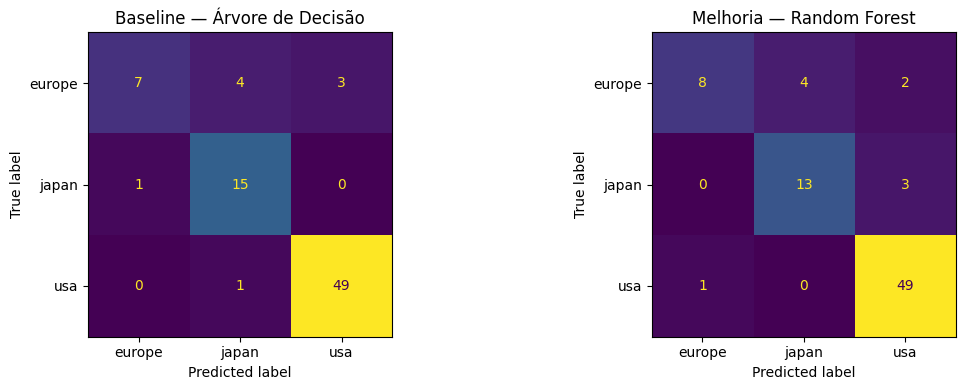

In [42]:
#Matriz de Confusão
classes = pipeline_baseline.classes_

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_baseline,
    display_labels=classes,
    ax=axes[0],
    colorbar=False
)
axes[0].set_title("Baseline — Árvore de Decisão")

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_rf,
    display_labels=classes,
    ax=axes[1],
    colorbar=False
)
axes[1].set_title("Melhoria — Random Forest")

plt.tight_layout()
plt.show()

### Interpretação dos Resultados
**Acurácia:** A Árvore de Decisão (0.89) superou levemente o Random Forest (0.88).
Isso acontece — modelos mais complexos não garantem melhoria, especialmente em
datasets pequenos (398 linhas).

**Relatório de Classificação:** Em ambos os modelos, a classe USA foi a mais fácil de classificar (f1 ≥ 0.94) — reflexo do desbalanceamento já identificado no diagnóstico, onde 62% dos exemplos são americanos. A classe EUROPE foi a mais
difícil em ambos os modelos, com recall de 0.50 no baseline e 0.57 no Random
Forest — ou seja, cerca de metade dos carros europeus foi classificada como
outra origem.

**Matriz de confusão:** Os erros se concentraram entre `europe` e `japan`,
confirmando o que o contexto histórico sugeria: ambas as regiões produziam
carros compactos e econômicos nos anos 1970–1982, com características técnicas
muito similares entre si.

No baseline, 4 carros europeus foram classificados como japoneses e 3 como
americanos. No Random Forest, 4 europeus foram classificados como japoneses e
2 como americanos — uma melhora pequena nessa classe. Por outro lado, o Random
Forest passou a confundir 3 carros japoneses como americanos, erro que não
existia no baseline, o que explica a queda no recall do Japão (0.94 → 0.81).

A classe USA foi a mais estável: apenas 1 erro em cada modelo, o que era
esperado dado o peso e potência superiores dos carros americanos no período.

## Parte 6 — Interpretação Humana dos Erros

**Para a classe EUROPE:**
- **FP:** o modelo disse que o carro é europeu, mas ele não é: O modelo "inventou" uma origem europeia para um carro que era japonês ou americano.
- **FN:** o carro é europeu, mas o modelo não reconheceu: Um carro europeu passou despercebido e foi classificado como japonês ou americano.

**Para a classe JAPAN:**
- **FP:** o modelo disse que o carro é japonês, mas ele não é.
- **FN:** o carro é japonês, mas o modelo classificou como europeu ou americano.

**Para a classe USA:**
- **FP:** o modelo disse que o carro é americano, mas ele não é.
- **FN:** o carro é americano, mas o modelo classificou como europeu ou japonês.

### Qual erro é mais grave neste contexto?

Neste dataset, os erros entre EUROPE E JAPAN são os menos graves,
pois ambas as regiões produziam carros com características técnicas muito
similares no período — compactos, leves e econômicos. Confundi-los tem
uma explicação técnica plausível.

O erro mais grave seria classificar um carro USA como europeu ou japonês
(FN de USA), pois os carros americanos tinham perfil técnico completamente
distinto: motores maiores, maior peso e maior consumo. Esse tipo de erro
indicaria uma falha estrutural no modelo, não apenas ambiguidade entre classes
parecidas.

---

### Em qual classe cada modelo errou mais?

**Baseline (Árvore de Decisão):** errou mais na classe EUROPE: 7 acertos em 14 exemplos (recall 0.50). Dos 7 erros, 4 foram classificados
como JAPAN e 3 como USA.

**Random Forest:** também errou mais na classe EUROPE: 8 acertos em 14 exemplos (recall 0.57). Melhorou levemente em relação ao baseline nessa classe, mas piorou em JAPAN: 3 carros japoneses foram classificados como americanos, erro que não existia no baseline.